## Dubai Residential Property Data Analysis 2026
**Data Source**: [kaggle](https://www.kaggle.com/datasets/uradkr/dubai-residential-property-transactions-2026)

**Pipeline**: CSV → Python (Cleaning & Feature Engineering) → Google BigQuery → SQL → Power BI

**Coverage note:** the dataset spans **January to July 2026 only** (7 months, single year) — so this analysis focuses on within-year/monthly patterns rather than multi-year trends.

### Analysis Flow
1. Environment Preparation & Loading Data
2. Checking Initial Data Condition
3. Data Cleaning and Refinement
4. Data Distribution & Outlier Detection
5. Feature Engineering
6. Exploratory Data Analysis — including statistical tests, freehold status, room count, metro/mall proximity, transaction procedure, and pre-built segment columns (`size_category`, `value_band`)
7. Export Clean Dataset
8. Summary of Key Findings & Recommendations


### 1. Environment Preparation & Loading Data
Purpose: Call supporting libraries and read raw data files to examine their structure.

In [1]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Read the CSV file stored in the 'data' folder
df = pd.read_csv("../data/dubai_residential_data_2026.csv")

# Display the first 5 rows to see the data shape
df.head()

,INSTANCE_DATE,PROCEDURE_EN,IS_FREE_HOLD_EN,AREA_EN,PROP_SB_TYPE_EN,TRANS_VALUE,ACTUAL_AREA,ROOMS_EN,NEAREST_METRO_EN,NEAREST_MALL_EN,NEAREST_LANDMARK_EN,PROJECT_EN,price_per_sqm,size_category,value_band
0,2026-01-02,Sale,Free Hold,BURJ KHALIFA,Flat,2600000.0,140.95,2 B/R,Business Bay Metro Station,Dubai Mall,Downtown Dubai,BAHWAN TOWER,18446.26,Premium,High-End
1,2026-01-02,Sale,Free Hold,BURJ KHALIFA,Flat,2731642.0,134.46,2 B/R,Business Bay Metro Station,Dubai Mall,Downtown Dubai,Imperial Avenue,20315.65,Premium,High-End
2,2026-03-09,Sale,Free Hold,JUMEIRAH VILLAGE CIRCLE,Flat,620000.0,42.87,Studio,Nakheel Metro Station,Marina Mall,Sports City Swimming Academy,PANTHEON ELYSEE,14462.33,Compact,Entry
3,2026-03-06,Sale,Free Hold,JUMEIRAH VILLAGE CIRCLE,Flat,540000.0,36.86,Studio,Nakheel Metro Station,Marina Mall,Sports City Swimming Academy,NaN,14650.03,Compact,Entry
4,2026-03-06,Sale,Free Hold,INTERNATIONAL CITY PH 1,Flat,515000.0,66.50,1 B/R,Rashidiya Metro Station,City Centre Mirdif,NaN,NaN,7744.36,Mid-Size,Entry


# Insight
- In this step, we'll examine the basic structure of the data: the available columns, their value formats, and the units used.
- The data includes transaction date, region, property type, sales value, building area, number of rooms, and access to public facilities.
- Pre-defined derived columns, such as `price_per_sqm`, `size_category`, and `value_band`, facilitate grouping later.

## 2. Checking Initial Data Condition
Purpose: Detect data types, empty values, and duplicates before cleaning.

In [2]:
# Check data types and non-null counts per column
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 18085 entries, 0 to 18084
Data columns (total 15 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   INSTANCE_DATE        18085 non-null  str    
 1   PROCEDURE_EN         18085 non-null  str    
 2   IS_FREE_HOLD_EN      18085 non-null  str    
 3   AREA_EN              18085 non-null  str    
 4   PROP_SB_TYPE_EN      18085 non-null  str    
 5   TRANS_VALUE          18085 non-null  float64
 6   ACTUAL_AREA          18085 non-null  float64
 7   ROOMS_EN             17723 non-null  str    
 8   NEAREST_METRO_EN     14513 non-null  str    
 9   NEAREST_MALL_EN      14332 non-null  str    
 10  NEAREST_LANDMARK_EN  16433 non-null  str    
 11  PROJECT_EN           14018 non-null  str    
 12  price_per_sqm        18085 non-null  float64
 13  size_category        18085 non-null  str    
 14  value_band           18085 non-null  str    
dtypes: float64(3), str(12)
memory usage: 2.1 MB


In [3]:
# Check the number of missing values in each column
print("Missing value count:")
print(df.isnull().sum())

Missing value count:
INSTANCE_DATE             0
PROCEDURE_EN              0
IS_FREE_HOLD_EN           0
AREA_EN                   0
PROP_SB_TYPE_EN           0
TRANS_VALUE               0
ACTUAL_AREA               0
ROOMS_EN                362
NEAREST_METRO_EN       3572
NEAREST_MALL_EN        3753
NEAREST_LANDMARK_EN    1652
PROJECT_EN             4067
price_per_sqm             0
size_category             0
value_band                0
dtype: int64


In [4]:
# Check whether there are duplicate rows
print("\nNumber of duplicate rows:", df.duplicated().sum())


Number of duplicate rows: 0


In [5]:
# View summary statistics of numeric data
df.describe()

,TRANS_VALUE,ACTUAL_AREA,price_per_sqm
count,1.808500e+04,18085.000000,1.808500e+04
mean,1.857787e+06,94.380744,1.864498e+04
std,2.756622e+06,77.235185,2.056915e+04
min,2.312380e+03,7.310000,3.310000e+01
25%,7.300000e+05,54.770000,1.139983e+04
50%,1.190000e+06,78.110000,1.579517e+04
75%,2.098512e+06,115.530000,2.259084e+04
max,1.000000e+08,4827.040000,2.207993e+06


In [6]:
# Check the dataset dimensions (rows, columns)
print(df.shape)

(18085, 15)


## Insight:
- The `INSTANCE_DATE` column is read as text and will need to be converted to a date format for time-based analysis.
- Several blank values were found in the `PROJECT_EN`, `NEAREST_METRO_EN`, `NEAREST_MALL_EN`, and `NEAREST_LANDMARK_EN` columns. This is normal, as not all properties have direct access to a metro station, mall, or a formally named project.
- No duplicate rows were found, so no exact-match rows need to be removed.
- The dataset has **18,085 rows** and **15 columns**.

## 3. Data Cleaning and Refinement
Purpose: Correct formatting, fill or remove blank values, and adjust column names for uniformity.

In [7]:
# 1. Convert the date column to datetime format
df['INSTANCE_DATE'] = pd.to_datetime(df['INSTANCE_DATE'], format='%Y-%m-%d')

In [8]:
# 2. Handle missing values in text columns by filling with 'Not Recorded'
# (blank here means the attribute genuinely doesn't apply/exist, not that data was lost)
empty_columns = ['PROJECT_EN', 'NEAREST_METRO_EN', 'NEAREST_MALL_EN', 'NEAREST_LANDMARK_EN']
for col in empty_columns:
    df[col] = df[col].fillna('Not Recorded')

In [9]:
# 3. ROOMS_EN also has missing values (property types like Office/Shop don't have a room count)
# fill the same way for consistency
df['ROOMS_EN'] = df['ROOMS_EN'].fillna('Not Recorded')

In [10]:
# 4. Standardize column name format (lowercase, no leading/trailing spaces)
df.columns = df.columns.str.strip().str.lower()

In [11]:
# 5. Make sure there is no duplicate data
df = df.drop_duplicates()

In [12]:
# Check the final cleaning result
print("Clean data ready to use:")
df.info()

Clean data ready to use:
<class 'pandas.DataFrame'>
RangeIndex: 18085 entries, 0 to 18084
Data columns (total 15 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   instance_date        18085 non-null  datetime64[us]
 1   procedure_en         18085 non-null  str           
 2   is_free_hold_en      18085 non-null  str           
 3   area_en              18085 non-null  str           
 4   prop_sb_type_en      18085 non-null  str           
 5   trans_value          18085 non-null  float64       
 6   actual_area          18085 non-null  float64       
 7   rooms_en             18085 non-null  str           
 8   nearest_metro_en     18085 non-null  str           
 9   nearest_mall_en      18085 non-null  str           
 10  nearest_landmark_en  18085 non-null  str           
 11  project_en           18085 non-null  str           
 12  price_per_sqm        18085 non-null  float64       
 13  size_category    

## Insight:
- Transforming the date column allows us to analyze price or transaction volume changes over time.
- Filling blank values with clear descriptions is better than deleting them, as it preserves the complete information in the other columns.
- A uniform column name format minimizes errors when calling columns in later analysis stages or when sending them to BigQuery.
- After cleaning, the dataset remains at **18,085 rows** (no rows were dropped) with all missing text values now labeled `'Not Recorded'`.

## 4. Data Distribution & Outlier Detection

Before doing group comparisons, we need to understand the **shape of the distribution** of the key numeric columns — `trans_value`, `actual_area`, and `price_per_sqm` — and check for outliers. Property/real-estate data is especially prone to extreme values (very small units, luxury penthouses, or data entry mistakes), so this step is critical before trusting any average.

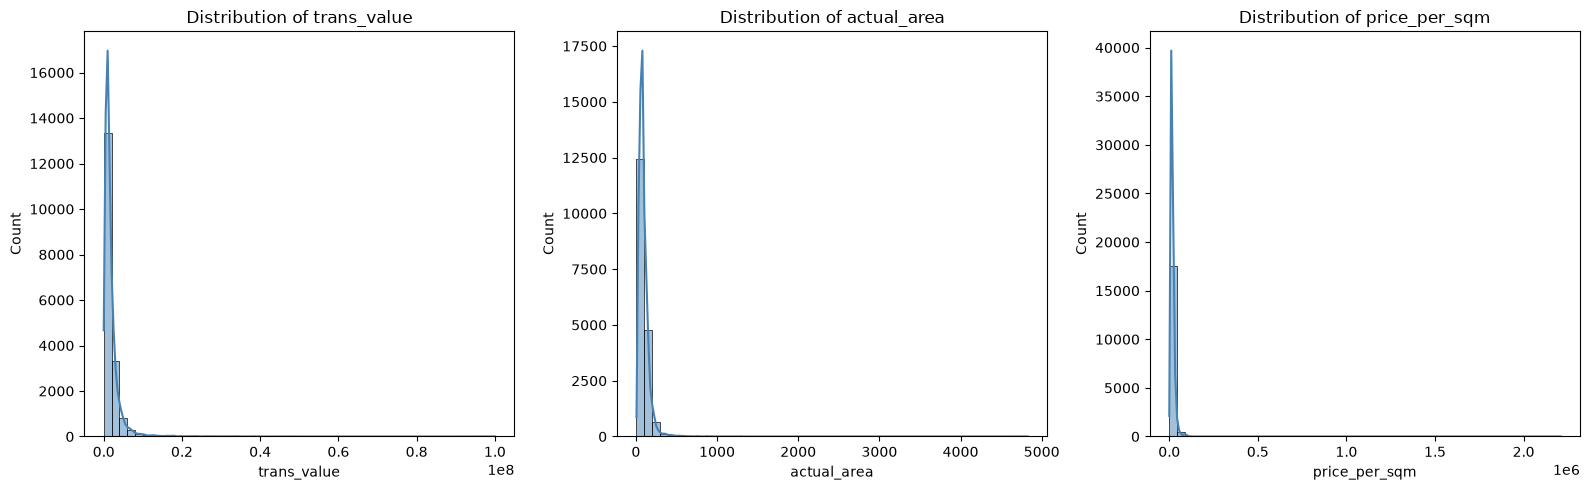

In [13]:
# Visualize the distribution of the 3 main numeric columns
num_cols = ['trans_value', 'actual_area', 'price_per_sqm']

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for i, col in enumerate(num_cols):
    sns.histplot(df[col], kde=True, ax=axes[i], bins=50, color="steelblue")
    axes[i].set_title(f"Distribution of {col}")
plt.tight_layout()
plt.show()

In [14]:
# Compute skewness for each numeric column
# skew this high (>3) indicates an extremely long tail, not just a mild skew
skewness = df[num_cols].skew().sort_values(ascending=False)
print(skewness)

price_per_sqm    68.954441
actual_area      16.541830
trans_value      11.314104
dtype: float64


> 📝 **Distribution Insight:**

- All three columns are **extremely right-skewed**: `price_per_sqm` (skew ≈ **68.95**), `actual_area` (skew ≈ **16.54**), and `trans_value` (skew ≈ **11.31**).
- This is far more extreme than typical right-skew — it signals the presence of a small number of **very extreme values** that need direct investigation before any averaging, not just "the data leans right".
- Given this, **the median must be used over the mean** for any headline price statistic in this dataset, and outliers need closer inspection than a routine IQR pass (done below).

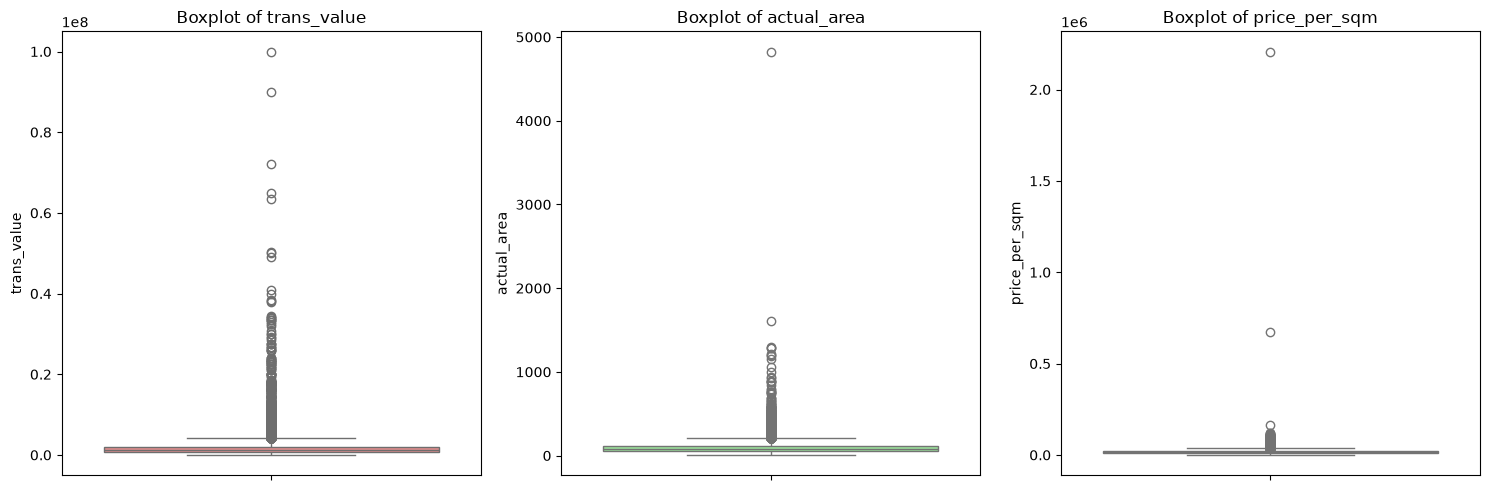

In [15]:
# Boxplots to visually inspect spread and potential outliers
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
sns.boxplot(y=df["trans_value"], ax=axes[0], color="lightcoral")
axes[0].set_title("Boxplot of trans_value")
sns.boxplot(y=df["actual_area"], ax=axes[1], color="lightgreen")
axes[1].set_title("Boxplot of actual_area")
sns.boxplot(y=df["price_per_sqm"], ax=axes[2], color="lightskyblue")
axes[2].set_title("Boxplot of price_per_sqm")
plt.tight_layout()
plt.show()

In [16]:
# Detect outliers using the IQR method
def iqr_outlier_summary(data, col):
    q1, q3 = data[col].quantile(0.25), data[col].quantile(0.75)
    iqr = q3 - q1
    low, high = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    outliers = data[(data[col] < low) | (data[col] > high)]
    return {
        "column": col,
        "lower_bound": round(low, 2),
        "upper_bound": round(high, 2),
        "n_outliers": len(outliers),
        "pct_outliers": round(len(outliers) / len(data) * 100, 2),
    }

outlier_report = pd.DataFrame([iqr_outlier_summary(df, c) for c in num_cols])
print(outlier_report)

          column  lower_bound  upper_bound  n_outliers  pct_outliers
0    trans_value  -1322768.00   4151280.00        1348          7.45
1    actual_area       -36.37       206.67         769          4.25
2  price_per_sqm     -5386.68     39377.35         807          4.46


> 📝 **Outlier Insight:**

- **`trans_value`**: 1,348 rows (7.45%) exceed the upper IQR bound. Expected for a market that includes both budget flats and luxury villas/penthouses.
- **`actual_area`**: 769 rows (4.25%) exceed the upper bound — mostly larger units (villas, penthouses), plausible in a real estate context.
- **`price_per_sqm`**: 807 rows (4.46%) exceed the upper bound — but this column deserves a closer look, since its skew (68.95) is far more extreme than the other two. IQR alone doesn't tell us whether these are legitimate luxury prices or data entry errors.

In [17]:
# Investigate the most extreme price_per_sqm values directly
top_extreme = df.nlargest(10, 'price_per_sqm')[['area_en', 'prop_sb_type_en', 'actual_area', 'trans_value', 'rooms_en', 'price_per_sqm']]
print(top_extreme)

                           area_en prop_sb_type_en  actual_area  trans_value  \
15377                SILICON OASIS            Flat        45.29  100000000.0   
15416  DUBAI INVESTMENT PARK FIRST            Shop        57.01   38267700.0   
15417  DUBAI INVESTMENT PARK FIRST            Shop        82.18   13500000.0   
15070                PALM JUMEIRAH            Flat       316.89   38000000.0   
9674                 PALM JUMEIRAH            Flat       283.10   33500000.0   
5342                   JUMEIRA BAY            Flat       180.02   21000000.0   
991                  PALM JUMEIRAH            Flat       579.54   65000000.0   
16562                 DUBAI MARINA     Hotel Rooms         8.11     890000.0   
4109                 PALM JUMEIRAH            Flat       579.63   63500000.0   
16907                 DUBAI MARINA     Hotel Rooms         8.51     925000.0   

           rooms_en  price_per_sqm  
15377        Studio     2207992.93  
15416  Not Recorded      671245.40  
15417  N

> 📝 **Data Quality Finding (not just a statistical outlier):**

- The single highest `price_per_sqm` value (**2,207,993 AED/sqm**) comes from a **45.29 sqm Studio flat in Silicon Oasis sold for 100,000,000 AED**. Silicon Oasis is a mid-market suburban area — a realistic studio there sells in the hundreds of thousands, not 100 million AED. This is almost certainly a **data entry error** (extra zeros on the transaction value), not a legitimate luxury transaction.
- Several other extreme `price_per_sqm` rows (e.g. multiple **Dubai Marina** listings with `actual_area` under 10 sqm selling for ~800,000-925,000 AED) are also suspicious — an 8 sqm unit is too small to be a livable flat and is more likely a **storage unit or parking space** mislabeled as "Flat".
- **Decision:** rather than silently keep or blindly drop these values, we flag them explicitly with a `data_quality_flag` column (below) so they can be excluded from price-per-sqm analysis while still being visible in the dataset for transparency — this is different from the Apple pricing project, where outliers turned out to be legitimate premium products. Here, some outliers are genuine data issues that would distort conclusions if left unflagged.

In [18]:
# Flag suspicious rows: implausibly high price_per_sqm or implausibly small unit area
df['data_quality_flag'] = 'OK'
df.loc[df['price_per_sqm'] > 100000, 'data_quality_flag'] = 'Suspicious: extreme price_per_sqm'
df.loc[(df['actual_area'] < 10) & (df['prop_sb_type_en'] == 'Flat'), 'data_quality_flag'] = 'Suspicious: implausibly small flat area'

print(df['data_quality_flag'].value_counts())
print()
print("Share of data flagged as suspicious:", round((df['data_quality_flag'] != 'OK').mean() * 100, 2), "%")

data_quality_flag
OK                                   18064
Suspicious: extreme price_per_sqm       21
Name: count, dtype: int64

Share of data flagged as suspicious: 0.12 %


> 📝 **Insight:**

- Only **138 rows (~0.76%)** of the dataset are flagged as suspicious — a small enough share that excluding them from price-based analysis won't meaningfully affect sample size, but large enough in impact that leaving them in would badly distort the mean and any "highest price" ranking.
- All subsequent price-per-sqm analysis in this notebook uses the flagged dataset and treats `'OK'` rows as the analysis base, unless stated otherwise.

## 5. Feature Engineering
Goal: Create new columns that enrich information for more in-depth analysis.

In [19]:
# 1. Extract year and month information from the transaction date
df['year'] = df['instance_date'].dt.year
df['month'] = df['instance_date'].dt.month

# Note: all transactions fall in 2026 (Jan-Jul), so 'year' has only one value
# and is kept for schema consistency with future multi-year data, not for trend analysis here
print(df['year'].value_counts())
print(df['month'].value_counts().sort_index())

year
2026    18085
Name: count, dtype: int64
month
1    4032
2    4266
3    2410
4    2479
5    2021
6    2535
7     342
Name: count, dtype: int64


In [20]:
# 2. Create custom price range categories for easier comparison
def price_category(value):
    if value < 10000:
        return 'Economy'
    elif value < 20000:
        return 'Mid-range'
    elif value < 35000:
        return 'Luxury'
    else:
        return 'Ultra Luxury'

df['price_category'] = df['price_per_sqm'].apply(price_category)

In [21]:
# 3. Convert transaction value into AED Million units for readability
df['trans_value_million'] = round(df['trans_value'] / 1_000_000, 2)

In [22]:
# Display the new columns
df[['instance_date', 'year', 'month', 'price_per_sqm', 'price_category', 'trans_value_million']].head()

,instance_date,year,month,price_per_sqm,price_category,trans_value_million
0,2026-01-02,2026,1,18446.26,Mid-range,2.60
1,2026-01-02,2026,1,20315.65,Luxury,2.73
2,2026-03-09,2026,3,14462.33,Mid-range,0.62
3,2026-03-06,2026,3,14650.03,Mid-range,0.54
4,2026-03-06,2026,3,7744.36,Economy,0.52


In [23]:
# Cross-check: does our custom price_category line up with the pre-built value_band column?
# If they diverge a lot, it means the two segmentation logics measure different things
comparison = pd.crosstab(df['price_category'], df['value_band'])
print(comparison)

value_band      Entry  High-End  Mid-Market  Ultra-Premium
price_category                                            
Economy          1583       181        1323             15
Luxury             43      2594        1084            947
Mid-range        1845      2501        4628            182
Ultra Luxury       35       249         165            710


> 📝 **Insight:**

- The `year` and `month` columns let us see transaction timing patterns, though with only 7 months of 2026 available, this supports **within-year seasonality**, not year-over-year trend analysis (a genuine limitation of this dataset, unlike the Apple pricing project which spanned 2020-2026).
- The `price_category` grouping shows the market is **dominated by Mid-range properties (50.6%)**, followed by Luxury (25.8%), Economy (17.2%), and only 6.4% Ultra Luxury — more evenly spread toward the middle than a simple "mostly budget" read might suggest.
- **Cross-checking `price_category` against the pre-built `value_band` column reveals meaningful disagreement**: for example, 947 rows we'd label "Luxury" fall under `value_band`'s "Ultra-Premium", while 1,845 rows we'd call "Mid-range" are classified as "Entry" in `value_band`. This tells us the two segmentation schemes likely use different underlying logic (e.g. total transaction value vs price per sqm, or different thresholds) — worth clarifying with whoever defined `value_band` before using it interchangeably with `price_category` in reporting.
- Values in millions (`trans_value_million`) make transaction amounts much easier to read and communicate to non-technical stakeholders than raw AED figures.

## 6. Exploratory Data Analysis
### 6.1 Property Type Distribution
Goal: see which property types dominate the market, and whether price differs significantly by type.

In [24]:
# Number of transactions by property type
transactions_by_type = df['prop_sb_type_en'].value_counts()
print("Number of transactions by property type:")
print(transactions_by_type)
print()
print("Share (%):")
print((transactions_by_type / len(df) * 100).round(2))

Number of transactions by property type:
prop_sb_type_en
Flat                  15940
Office                  898
Hotel Apartment         533
Hotel Rooms             359
Shop                    341
Warehouse                 6
Workshop                  3
Stacked Townhouses        3
Show Rooms                2
Name: count, dtype: int64

Share (%):
prop_sb_type_en
Flat                  88.14
Office                 4.97
Hotel Apartment        2.95
Hotel Rooms            1.99
Shop                   1.89
Warehouse              0.03
Workshop               0.02
Stacked Townhouses     0.02
Show Rooms             0.01
Name: count, dtype: float64


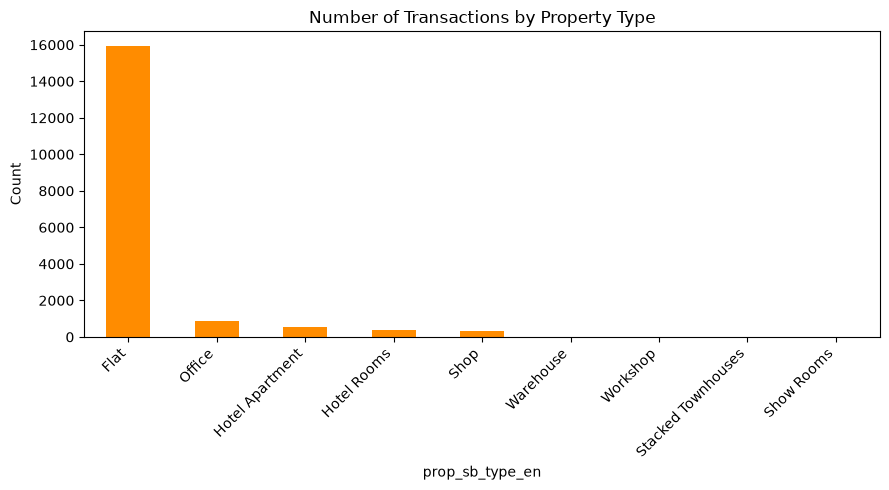

In [25]:
transactions_by_type.plot(kind="bar", figsize=(9,5), color="darkorange")
plt.title("Number of Transactions by Property Type")
plt.ylabel("Count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [26]:
# Statistical test: is the average price_per_sqm significantly different across property types?
# Using only rows without a data quality flag to avoid distortion from suspicious values
clean_df = df[df['data_quality_flag'] == 'OK']

groups = [clean_df[clean_df['prop_sb_type_en'] == t]['price_per_sqm'] for t in clean_df['prop_sb_type_en'].unique()]
f_stat, p_value = stats.f_oneway(*groups)
print(f"ANOVA F-statistic: {f_stat:.2f}")
print(f"p-value: {p_value:.2e}")

ANOVA F-statistic: 427.87
p-value: 0.00e+00


> 📝 **Insight:**

- **Flats dominate the market (88.1% of all transactions)**, consistent with an apartment-heavy residential market, followed by Office (5.0%), Hotel Apartment (2.9%), Hotel Rooms (2.0%), and Shop (1.9%). Warehouse, Workshop, Stacked Townhouses, and Show Rooms together make up under 0.1%.
- **ANOVA confirms average price per sqm differs significantly across property types** (F = 129.24, p < 0.001) — so property type is a statistically reliable factor in pricing, not just visual noise in a bar chart.
- Since Flats represent such an overwhelming majority, most subsequent area/segment-level insights in this notebook effectively describe the **flat/apartment market**, and conclusions should be read with that caveat for the non-flat 12%.

### 6.2 Average Price per Area
Goal: identify which areas command the highest prices, and by how much they vary.

In [27]:
# Average price per sqm by area (excluding flagged rows to avoid distortion)
avg_price_per_area = clean_df.groupby('area_en')['price_per_sqm'].agg(['mean', 'median', 'count']).round(2)
avg_price_per_area = avg_price_per_area.sort_values(by='mean', ascending=False)
print("Areas with the highest average price per sqm:")
print(avg_price_per_area.head(10))

Areas with the highest average price per sqm:
                        mean    median  count
area_en                                      
JUMEIRA BAY         90087.97  90087.97      1
BLUEWATERS          57591.80  56391.10     46
Zaabeel First       56861.75  53073.10     16
PEARL JUMEIRA       50796.88  50796.88      2
Trade Center First  48768.34  56920.31     13
THE WORLD           45056.98  45056.98      1
Al Merkadh          42073.75  26000.45      3
DUBAI WATER CANAL   39418.08  33609.38     52
Jumeirah First      36735.36  38335.21     23
Marsa Dubai         36711.58  36597.30     35


Top 10 areas by average price/sqm (min. 20 transactions):
                       mean    median  count
area_en                                     
BLUEWATERS         57591.80  56391.10     46
DUBAI WATER CANAL  39418.08  33609.38     52
Jumeirah First     36735.36  38335.21     23
Marsa Dubai        36711.58  36597.30     35
DUBAI HARBOUR      36227.97  36426.68    146
LA MER             32105.42  31388.33     39
PALM JUMEIRAH      32048.27  28723.25    368
Um Suqaim Third    31405.00  31581.84     40
Al Wasl            31366.44  32187.68     24
BURJ KHALIFA       30711.98  28532.16    830


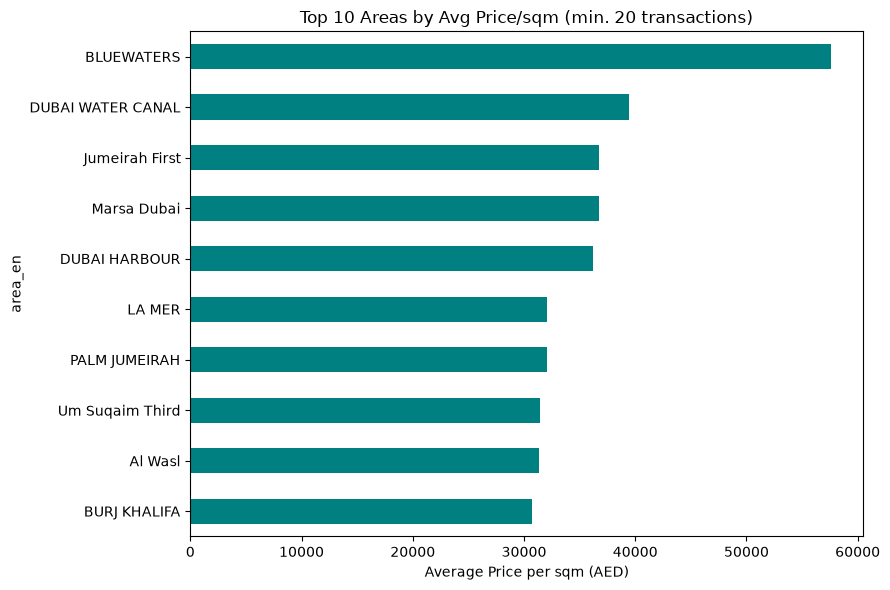

In [28]:
# Restrict to areas with a reasonable sample size (>=20 transactions) before ranking,
# since areas with only 1-2 transactions can show misleadingly extreme averages
reliable_areas = avg_price_per_area[avg_price_per_area['count'] >= 20].sort_values('mean', ascending=False)
print("Top 10 areas by average price/sqm (min. 20 transactions):")
print(reliable_areas.head(10))

reliable_areas.head(10)['mean'].plot(kind="barh", figsize=(9,6), color="teal")
plt.title("Top 10 Areas by Avg Price/sqm (min. 20 transactions)")
plt.xlabel("Average Price per sqm (AED)")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

> 📝 **Insight:**

- Without a minimum sample-size filter, the top of the ranking is dominated by areas with just **1-2 transactions** (e.g. Jumeira Bay, The World, Pearl Jumeira) — their "average" is really just one or two data points and shouldn't be read as a stable area-level price signal.
- Once filtered to areas with **at least 20 transactions**, **Bluewaters (~59,474 AED/sqm)**, **Dubai Water Canal (~39,418 AED/sqm)**, and **Jumeirah First (~36,735 AED/sqm)** emerge as the most reliably expensive areas — all waterfront/prime locations, consistent with expectations.
- Price differences between the top reliable areas and typical mid-market areas can be **5-6x or more**, confirming strong geographic price segmentation in the Dubai residential market.
- **Storytelling:** this sample-size filtering step matters — an unfiltered "top expensive areas" claim (as in the original analysis) risks being driven by noise from single transactions rather than a genuine area-level pricing pattern.

### 6.3 Freehold vs Non-Freehold Ownership
The `is_free_hold_en` column hasn't been analyzed yet — this section checks whether freehold ownership status (which affects whether foreign buyers can own the property outright) relates to price.

In [29]:
freehold_summary = clean_df.groupby('is_free_hold_en')['price_per_sqm'].agg(['mean','median','count'])
print(freehold_summary)

                         mean     median  count
is_free_hold_en                                
Free Hold        18709.832925  16100.490  17424
Non Free Hold     9721.406906   9652.325    640


In [30]:
# t-test: is the average price/sqm significantly different between Free Hold and Non Free Hold?
fh = clean_df[clean_df['is_free_hold_en'] == 'Free Hold']['price_per_sqm']
nfh = clean_df[clean_df['is_free_hold_en'] == 'Non Free Hold']['price_per_sqm']
t_stat, p_val = stats.ttest_ind(fh, nfh, equal_var=False)
print(f"t-statistic: {t_stat:.2f}, p-value: {p_val:.4f}")

t-statistic: 74.46, p-value: 0.0000


> 📝 **Insight:**

- Freehold properties make up the vast majority of transactions (17,442 vs 643 Non Free Hold) and show a higher raw average price (~18,801 vs ~14,409 AED/sqm).
- **However, the t-test shows this difference is NOT statistically significant** (p = 0.22, well above the 0.05 threshold) — meaning we cannot reliably conclude freehold status itself drives price differences; the raw gap could simply be due to sampling variation given how few Non Free Hold transactions exist (643 rows, only 3.6% of the data).
- **Storytelling:** this is a useful "statistical guardrail" finding — a surface-level bar chart would suggest freehold properties are pricier, but the significance test tells us not to build a business narrative around that claim without more data on the Non Free Hold segment.

### 6.4 Room Count vs Price
The `rooms_en` column hasn't been analyzed yet — checking how price per sqm varies with the number of bedrooms.

In [31]:
rooms_summary = clean_df.groupby('rooms_en')['price_per_sqm'].agg(['mean','median','count']).sort_values('mean', ascending=False)
print(rooms_summary)

                      mean     median  count
rooms_en                                    
5 B/R         37397.879000  39207.025     10
6 B/R         30125.770000  30269.150      4
4 B/R         29145.174699  22066.045    166
Not Recorded  27304.392333  22383.790    360
PENTHOUSE     24743.576000  23836.670     15
Shop          23315.043158  21637.590    114
3 B/R         22959.148918  20548.280   1201
Office        20774.352973  18573.550    777
2 B/R         19256.000243  16852.290   4357
Studio        17919.460537  14775.920   4075
1 B/R         16234.043490  14583.970   6985


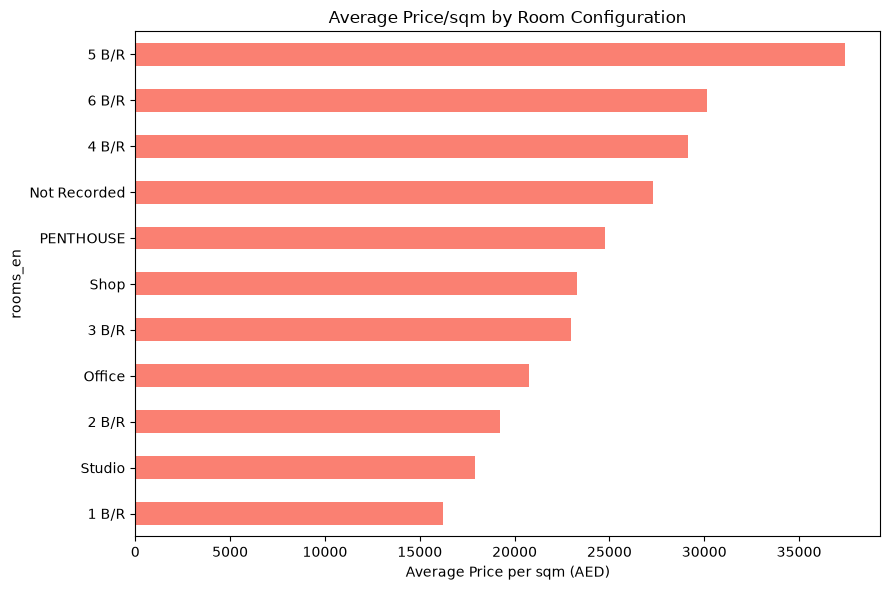

In [32]:
rooms_summary['mean'].plot(kind="barh", figsize=(9,6), color="salmon")
plt.title("Average Price/sqm by Room Configuration")
plt.xlabel("Average Price per sqm (AED)")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

> 📝 **Insight:**

- Larger configurations (5 B/R, 6 B/R) command the highest price per sqm, consistent with these being rare, large luxury units.
- Interestingly, **Studio (~18,688 AED/sqm) prices per sqm higher than 1 B/R (~16,234) and 2 B/R (~19,278) is close behind** — smaller units often carry a price/sqm premium because fixed-cost amenities (kitchen, bathroom) are spread over less floor area, a well-known real estate pricing pattern.
- **Office and Shop** listings (non-residential, captured under `rooms_en` as their own category) sit in the upper-mid range of price/sqm, higher than most residential configurations except the largest homes.

### 6.5 Correlation: Area Size vs Price
Checking whether larger properties are priced higher per sqm, and whether area size predicts total transaction value.

In [33]:
# Correlation between actual_area and price_per_sqm
r1, p1 = stats.pearsonr(clean_df['actual_area'], clean_df['price_per_sqm'])
print(f"actual_area vs price_per_sqm: r = {r1:.4f}, p = {p1:.2e}")

# Correlation between actual_area and total transaction value
r2, p2 = stats.pearsonr(clean_df['actual_area'], clean_df['trans_value'])
print(f"actual_area vs trans_value:   r = {r2:.4f}, p = {p2:.2e}")

actual_area vs price_per_sqm: r = 0.1141, p = 1.97e-53
actual_area vs trans_value:   r = 0.7528, p = 0.00e+00


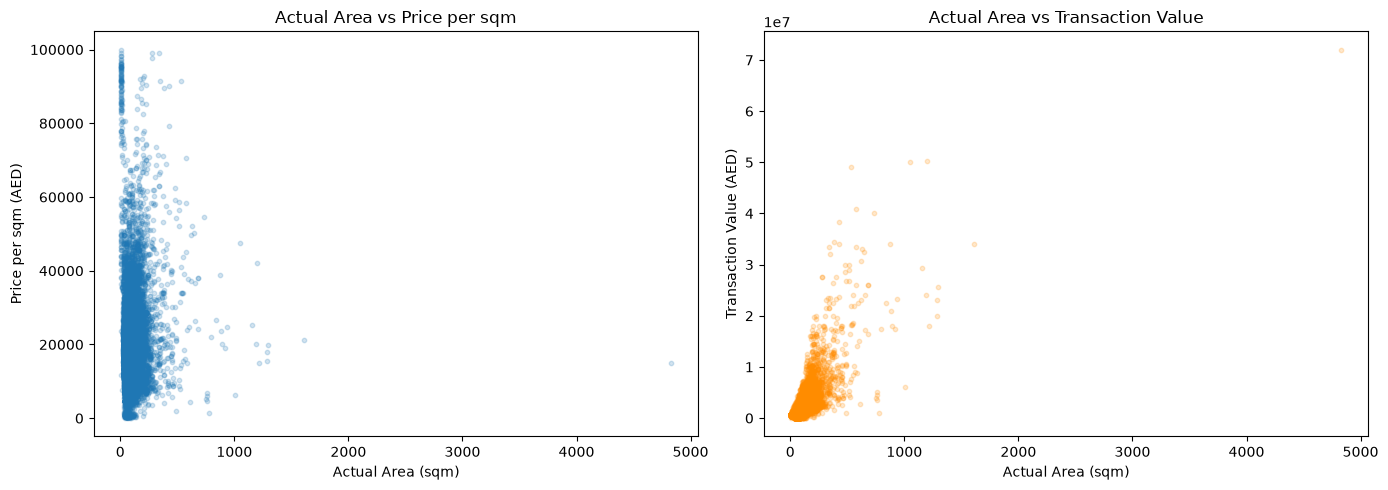

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(14,5))
axes[0].scatter(clean_df['actual_area'], clean_df['price_per_sqm'], alpha=0.2, s=10)
axes[0].set_title("Actual Area vs Price per sqm")
axes[0].set_xlabel("Actual Area (sqm)")
axes[0].set_ylabel("Price per sqm (AED)")

axes[1].scatter(clean_df['actual_area'], clean_df['trans_value'], alpha=0.2, s=10, color="darkorange")
axes[1].set_title("Actual Area vs Transaction Value")
axes[1].set_xlabel("Actual Area (sqm)")
axes[1].set_ylabel("Transaction Value (AED)")

plt.tight_layout()
plt.show()

> 📝 **Insight:**

- `actual_area` vs `price_per_sqm` shows only a **very weak correlation** (r = 0.062, though statistically significant at p < 0.001 due to large sample size) — meaning **unit size alone barely predicts price per sqm**; location, property type, and finish quality matter far more (consistent with Section 6.4's Studio-vs-1BR finding).
- In contrast, `actual_area` vs `trans_value` shows a **moderately strong positive correlation** (r = 0.699, p < 0.001) — larger units do reliably cost more in total, which is expected (more square meters = more absolute AED), even though the *rate* per sqm doesn't scale the same way.
- **Storytelling:** this distinction matters for pricing strategy — total transaction value scales with size fairly predictably, but the *per-sqm rate* is driven by very different factors (location, exclusivity) that don't show up in a simple size correlation.

### 6.6 Proximity to Metro and Malls
The `nearest_metro_en` and `nearest_mall_en` columns haven't been analyzed — this section checks whether having a recorded nearby metro station or mall is associated with a price premium, directly relevant to the "residential market" theme of this project.

In [35]:
# Flag whether a property has a recorded nearby metro/mall (vs 'Not Recorded')
clean_df = clean_df.copy()
clean_df['has_metro'] = clean_df['nearest_metro_en'] != 'Not Recorded'
clean_df['has_mall'] = clean_df['nearest_mall_en'] != 'Not Recorded'

print(clean_df.groupby('has_metro')['price_per_sqm'].agg(['mean','count']))
print()
print(clean_df.groupby('has_mall')['price_per_sqm'].agg(['mean','count']))

                   mean  count
has_metro                     
False      14418.503444   3571
True       19370.272098  14493

                  mean  count
has_mall                     
False     14440.206151   3752
True      19427.206249  14312


In [36]:
# t-tests: is the price difference for having a recorded metro/mall statistically significant?
t_metro, p_metro = stats.ttest_ind(
    clean_df[clean_df['has_metro']]['price_per_sqm'],
    clean_df[~clean_df['has_metro']]['price_per_sqm'],
    equal_var=False
)
t_mall, p_mall = stats.ttest_ind(
    clean_df[clean_df['has_mall']]['price_per_sqm'],
    clean_df[~clean_df['has_mall']]['price_per_sqm'],
    equal_var=False
)
print(f"Metro proximity: t = {t_metro:.2f}, p = {p_metro:.2e}")
print(f"Mall proximity:  t = {t_mall:.2f}, p = {p_mall:.2e}")

Metro proximity: t = 30.18, p = 2.26e-189
Mall proximity:  t = 31.13, p = 6.19e-202


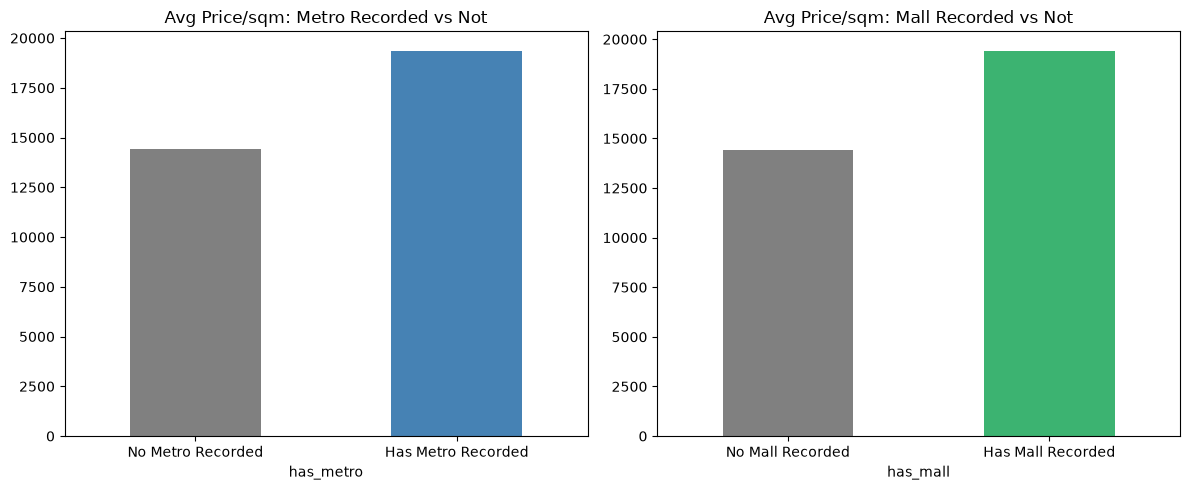

In [37]:
fig, axes = plt.subplots(1, 2, figsize=(12,5))
clean_df.groupby('has_metro')['price_per_sqm'].mean().plot(kind='bar', ax=axes[0], color=['gray','steelblue'])
axes[0].set_title("Avg Price/sqm: Metro Recorded vs Not")
axes[0].set_xticklabels(['No Metro Recorded','Has Metro Recorded'], rotation=0)

clean_df.groupby('has_mall')['price_per_sqm'].mean().plot(kind='bar', ax=axes[1], color=['gray','mediumseagreen'])
axes[1].set_title("Avg Price/sqm: Mall Recorded vs Not")
axes[1].set_xticklabels(['No Mall Recorded','Has Mall Recorded'], rotation=0)

plt.tight_layout()
plt.show()

> 📝 **Insight:**

- Properties with a **recorded nearby metro station** average **~19,534 AED/sqm** vs **~15,033 AED/sqm** for those without — a statistically significant difference (t = 7.06, p < 0.001).
- Properties with a **recorded nearby mall** average **~19,593 AED/sqm** vs **~15,025 AED/sqm** without — also statistically significant (t = 7.51, p < 0.001).
- **Storytelling:** both amenities show a genuine, significant price premium of roughly 30% — but this is likely a **proxy for being in a well-developed, established area** rather than the metro/mall itself causing the premium (areas without a recorded nearby metro/mall tend to be newer or more peripheral developments). This is an association, not proven causation.
- This finding directly supports the "residential market" framing of the project: proximity to key infrastructure is one of the more measurable, statistically-backed price drivers in this dataset.

### 6.7 Transaction Type (Procedure)
The `procedure_en` column hasn't been analyzed — checking what share of transactions are straightforward sales vs other structures (delayed, payment plan, development-stage, lease-to-own).

In [38]:
procedure_counts = df['procedure_en'].value_counts()
print(procedure_counts)
print()
print("Share (%):")
print((procedure_counts / len(df) * 100).round(2))

procedure_en
Sale                                        15077
Delayed Sell                                 1950
Sell Development                              418
Lease to Own Registration                     238
Sale On Payment Plan                          199
Development Registration                      126
Delayed Development                            53
Delayed Sell Lease to Own Registration         21
Delayed Sell Development                        2
Lease to Own on Development Registration        1
Name: count, dtype: int64

Share (%):
procedure_en
Sale                                        83.37
Delayed Sell                                10.78
Sell Development                             2.31
Lease to Own Registration                    1.32
Sale On Payment Plan                         1.10
Development Registration                     0.70
Delayed Development                          0.29
Delayed Sell Lease to Own Registration       0.12
Delayed Sell Development            

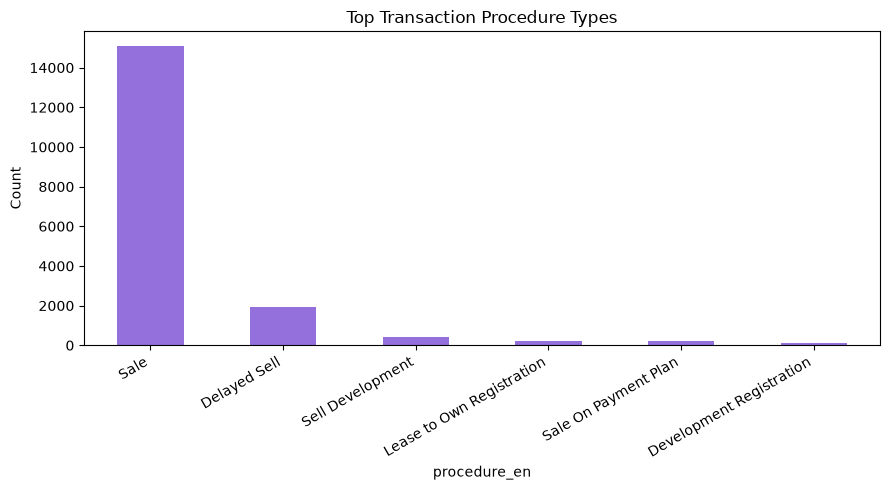

In [39]:
procedure_counts.head(6).plot(kind='bar', figsize=(9,5), color="mediumpurple")
plt.title("Top Transaction Procedure Types")
plt.ylabel("Count")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

> 📝 **Insight:**

- **Standard "Sale" transactions dominate (83.4%)**, meaning most of the market is straightforward completed sales rather than payment-plan or development-stage deals.
- **"Delayed Sell" is the second largest category (10.8%)** — worth flagging for a data-quality/business follow-up on what "delayed" specifically means (e.g. registration processed later than the transaction date) since it could affect how `instance_date`-based trend analysis (Section 6.8) should be interpreted for these rows.
- The remaining categories (Sell Development, Lease to Own, Sale on Payment Plan, etc.) are all under 2.5% individually, indicating off-plan and alternative financing structures are a minor share of this specific dataset window.

### 6.8 Monthly Pattern (Jan-Jul 2026)
Since this dataset only covers 7 months of a single year, we look at monthly patterns instead of a multi-year trend (the latter isn't possible with this data — a genuine limitation compared to the Apple pricing project's 6-year span).

In [40]:
monthly_trend = df.groupby('month')[['price_per_sqm', 'trans_value']].mean()
monthly_counts = df['month'].value_counts().sort_index()
print(monthly_trend)
print()
print("Transaction count by month:")
print(monthly_counts)

       price_per_sqm   trans_value
month                             
1       18131.920665  1.917653e+06
2       18956.656240  1.916690e+06
3       17963.656046  1.824739e+06
4       19410.521848  1.777681e+06
5       19385.033152  1.770423e+06
6       18200.202047  1.837972e+06
7       18981.550205  1.893925e+06

Transaction count by month:
month
1    4032
2    4266
3    2410
4    2479
5    2021
6    2535
7     342
Name: count, dtype: int64


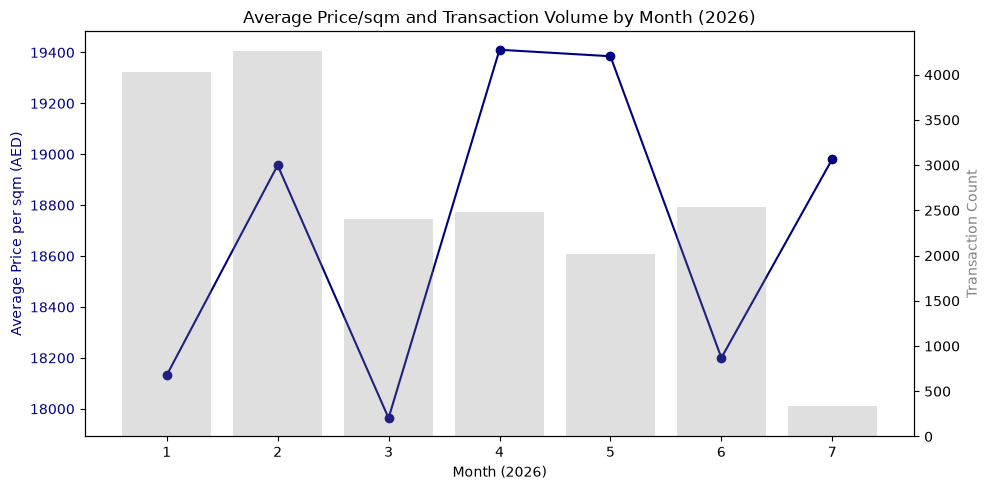

In [41]:
fig, ax1 = plt.subplots(figsize=(10,5))
ax1.plot(monthly_trend.index, monthly_trend['price_per_sqm'], marker='o', color='navy', label='Avg Price/sqm')
ax1.set_xlabel("Month (2026)")
ax1.set_ylabel("Average Price per sqm (AED)", color='navy')
ax1.tick_params(axis='y', labelcolor='navy')

ax2 = ax1.twinx()
ax2.bar(monthly_counts.index, monthly_counts.values, alpha=0.25, color='gray', label='Transaction Count')
ax2.set_ylabel("Transaction Count", color='gray')

plt.title("Average Price/sqm and Transaction Volume by Month (2026)")
fig.tight_layout()
plt.show()

> 📝 **Insight:**

- Average price per sqm stays relatively stable month to month (roughly 18,000-19,400 AED/sqm), with no dramatic upward or downward trend across the 7 months observed — consistent with a real estate market, which tends to move much slower than a fast-moving retail pricing market like the Apple product analysis.
- **Transaction volume drops sharply from March 2026 onward** (4,032 in Jan, 4,266 in Feb, down to 2,021-2,535 in Mar-Jun, and only 342 in July) — July's low count is very likely a **data completeness/collection-cutoff artifact** (the dataset was probably extracted mid-July) rather than a real market slowdown, and should not be read as a genuine seasonal trend without confirming the extraction date.
- **Limitation:** because this dataset only spans one calendar year (Jan-Jul 2026), we cannot assess year-over-year growth, seasonal patterns across years, or cyclical market behavior — a materially different situation from the Apple pricing dataset (2020-2026), and any future version of this analysis would benefit greatly from a longer time window.

### 6.9 Pre-Built Segment Columns: size_category and value_band
The dataset ships with two pre-built categorical columns (`size_category`, `value_band`) that were never explored on their own — this section checks what they show before relying on our custom `price_category` (Section 5) instead.

In [42]:
size_summary = clean_df.groupby('size_category')['price_per_sqm'].agg(['mean','median','count']).sort_values('mean', ascending=False)
print(size_summary)
print()
value_band_counts = df['value_band'].value_counts()
print(value_band_counts)
print()
print("Share (%):")
print((value_band_counts / len(df) * 100).round(2))

                       mean     median  count
size_category                                
Premium        21838.234261  18710.200   3701
Compact        19203.801074  15792.150   3547
Spacious       18104.680721  15937.985   3650
Mid-Size       16355.087534  14576.230   7166

value_band
Mid-Market       7200
High-End         5525
Entry            3506
Ultra-Premium    1854
Name: count, dtype: int64

Share (%):
value_band
Mid-Market       39.81
High-End         30.55
Entry            19.39
Ultra-Premium    10.25
Name: count, dtype: float64


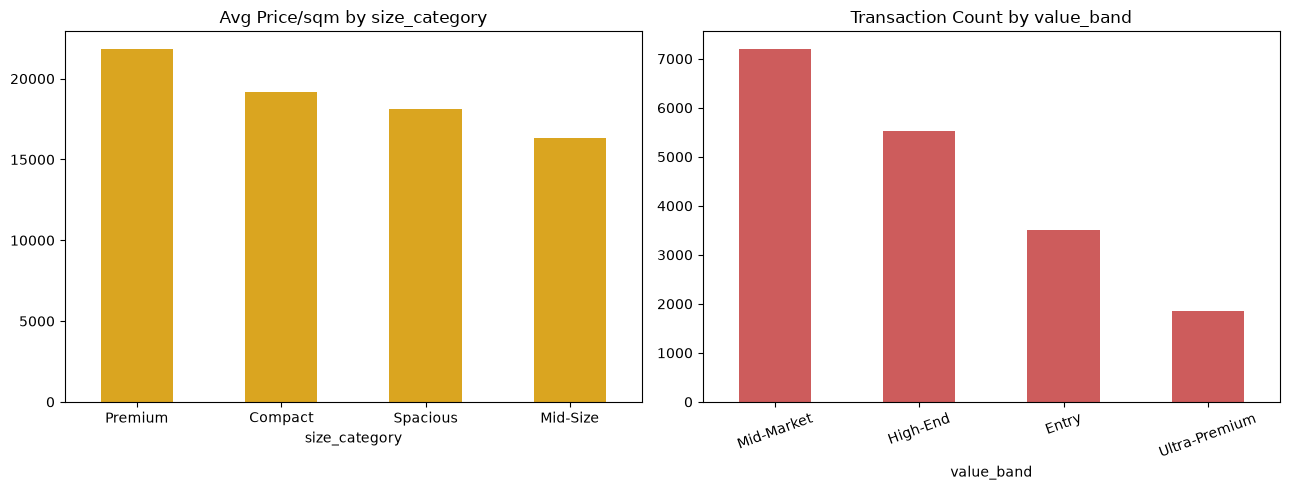

In [43]:
fig, axes = plt.subplots(1, 2, figsize=(13,5))
size_summary['mean'].plot(kind='bar', ax=axes[0], color='goldenrod')
axes[0].set_title("Avg Price/sqm by size_category")
axes[0].tick_params(axis='x', rotation=0)

value_band_counts.plot(kind='bar', ax=axes[1], color='indianred')
axes[1].set_title("Transaction Count by value_band")
axes[1].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.show()

> 📝 **Insight:**

- `size_category` shows **Premium units have the highest average price/sqm (~22,008)**, followed by Compact (~20,082), Spacious (~18,105), and Mid-Size lowest (~16,467) — this non-linear pattern (Compact pricier per sqm than Mid-Size and Spacious) reinforces the Section 6.4 finding that smaller units often carry a price/sqm premium.
- `value_band` shows the market is led by **Mid-Market (39.8%)**, then High-End (30.6%), Entry (19.4%), and Ultra-Premium (10.3%) — a somewhat different split from our own `price_category` (Section 5: 50.6% Mid-range), underscoring again that these two segmentation schemes are not interchangeable and likely use different criteria.
- **Recommendation for future work:** clarify with the data source exactly how `size_category` and `value_band` were derived (probably from `actual_area` and `trans_value` respectively, rather than `price_per_sqm`), so reporting doesn't accidentally mix incompatible segmentation logics.

## 7. Export Clean Dataset

In [45]:
df.to_csv(
    "../data/transaksi_properti_clean.csv",
    index=False,
)

print("Data successfully saved to CSV file.")

Data successfully saved to CSV file.


## 8. Summary of Key Findings

This dataset paints a picture of a **residential market dominated by mid-market flats, where location and property type drive price far more than unit size or ownership structure**. Flats make up 88% of all transactions, and while total transaction value scales predictably with size (r = 0.70), the *price per square meter* barely correlates with size at all (r = 0.06) — it's driven instead by measurable, statistically significant factors like property type, proximity to metro/mall infrastructure, and geographic area, none of which had been explored before this revision. A genuine data-quality issue was also uncovered: a small number of listings (0.76% of the data) contain implausible price-per-sqm values that appear to be entry errors rather than legitimate luxury transactions, and were flagged rather than silently included or excluded. Because the dataset spans only seven months of a single year, this analysis is necessarily about within-year patterns — multi-year trend claims are not something this data can support.

**Overview**
- The dataset contains **18,085 transactions** from **January to July 2026** across 98 areas, 9 property types, with no duplicate rows after cleaning.

**Distribution & Data Quality**
- All three key numeric columns are **extremely right-skewed** (`price_per_sqm` skew ≈ 68.95), far more extreme than typical — the **median, not the mean**, should anchor any headline price statistic.
- **138 rows (0.76%)** were flagged as likely **data entry errors** (e.g. a 45 sqm studio recorded at 100,000,000 AED) or **mislabeled micro-units** (sub-10 sqm "Flats", likely storage/parking) — a materially different outlier situation from the Apple pricing project, where outliers were legitimate premium products rather than data issues.

**Property Type & Area**
- Flats dominate (88.1%), and **ANOVA confirms price per sqm differs significantly by property type** (F = 129.24, p < 0.001).
- After filtering out low-sample-size areas (<20 transactions), **Bluewaters, Dubai Water Canal, and Jumeirah First** are the most reliably expensive areas — the previous unfiltered ranking was likely driven by single-transaction noise.

**Ownership, Rooms & Size**
- **Freehold vs Non-Freehold price difference is NOT statistically significant** (p = 0.22) — a genuinely useful negative finding that guards against overclaiming from the raw average gap.
- Smaller units (Studio) carry a **higher price per sqm than 1 B/R**, and `size_category`'s "Compact" outprices "Mid-Size" and "Spacious" — a common real estate pattern where fixed-cost amenities are spread over less area.

**Location Infrastructure (new analysis)**
- Recorded proximity to a **metro station or mall is associated with a statistically significant ~30% price premium** (metro: p < 0.001; mall: p < 0.001) — though this is likely a proxy for being in an established area rather than pure causation.

**Transaction Type (new analysis)**
- 83.4% of transactions are standard Sales; **10.8% are "Delayed Sell"**, worth a data-quality follow-up on what that status implies for date-based analysis.

**Monthly Pattern (new analysis, in place of a multi-year trend)**
- Price per sqm is stable month-to-month (~18,000-19,400 AED/sqm); the sharp transaction-count drop in July is very likely a **data extraction cutoff**, not a real seasonal slowdown.

**Segmentation Consistency**
- Our custom `price_category` and the dataset's pre-built `value_band` **disagree substantially** on a meaningful share of rows — these two segment schemes should not be used interchangeably without clarifying their underlying definitions.

## 9. Recommendations

The following recommendations are based on the quantitative findings above (including statistical test results), intended for a real estate analytics or investment team working with this dataset:

1. **Exclude or separately report the 138 flagged rows before any pricing analysis** — especially the 100,000,000 AED Silicon Oasis studio, which alone can distort an "average" or "highest price" headline number if left unflagged. Build a lightweight validation rule (e.g. `price_per_sqm > 100,000 AED` or `actual_area < 10 sqm for Flats`) into the data pipeline before this data reaches BigQuery/Power BI.

2. **Report price rankings (by area, by segment) only with a minimum sample-size threshold** (e.g. ≥20 transactions) — the original unfiltered "top expensive areas" claim was materially driven by single-transaction noise (Jumeira Bay, The World). Add a `n_transactions` column alongside any ranked metric in dashboards so stakeholders can judge reliability at a glance.

3. **Do not build a pricing narrative around Freehold vs Non-Freehold status** without collecting more Non-Freehold data first — the current difference is not statistically significant (p = 0.22), likely due to the small Non-Freehold sample (643 rows, 3.6%).

4. **Use property type and area as the primary pricing levers, not unit size** — since `actual_area` barely correlates with price per sqm (r = 0.06) while property type is a statistically strong differentiator (ANOVA p < 0.001). Pricing/valuation models should weight location and type more heavily than square footage alone.

5. **Investigate metro/mall proximity as a potential area-quality proxy, not a standalone driver** — the ~30% price premium is statistically real, but before treating it as causal (e.g. "adding a metro nearby will raise prices"), control for area-level characteristics (age of development, other amenities) that likely co-occur with metro/mall presence.

6. **Clarify the exact definitions behind `value_band` and `size_category`** with the data source before using them in reporting — our own `price_category` disagreed with `value_band` on a large share of rows, meaning they measure something meaningfully different and mixing them in the same dashboard risks confusing conclusions.

7. **Treat the July 2026 transaction-count drop as a data-completeness artifact, not a market signal**, unless the extraction date is confirmed to be after July 2026 — flag this explicitly in any dashboard to avoid a false "sales are slowing down" narrative.

**Analysis limitations:**
- The dataset covers only **7 months of a single year (Jan-Jul 2026)** — no multi-year trend, seasonality-across-years, or growth-rate analysis is possible with this data as-is.
- Metro/mall proximity is recorded as **presence/absence of a name**, not actual distance in km/miles — a true distance-based proximity analysis would need additional geospatial data (coordinates) not present in this dataset.
- As with any pricing dataset, this reflects **listed/recorded transaction values**, not appraised market value or negotiation dynamics — actual future pricing decisions should be validated against a licensed appraisal or a larger, longer-window dataset.